# Exercise 1: Introduction to image manipulation using Python

## 1.  Install dependencies if needed 

just run ```uv sync```.

## 2. Read images


- Download the Sentinel-2 images from [here](https://drive.google.com/file/d/1oPmyt6jvYrSge2N_uJHRDPIfWWXVGC6a/view?usp=sharing). 
- Place the downloaded .zip file to the same folder as this notebook

In [1]:
import zipfile
import os

with zipfile.ZipFile("image_week1_tif.zip", 'r') as zip_ref:
    zip_ref.extractall()
    
print(os.listdir("image_week1_tif"))

['band4.tif', 'band3.tif', 'band2.tif', 'band8.tif']


Read the images using the function ***imread*** of the ***skimage*** library

In [2]:
from skimage.io import imread, imsave
import numpy as np

# TODO: Use the library skimage to read the images
band2_array = imread("image_week1_tif/band2.tif")
band3_array = imread("image_week1_tif/band3.tif")
band4_array = imread("image_week1_tif/band4.tif")
band8_array = imread("image_week1_tif/band8.tif")

## 3. Save multi-band images on tif files, and visualize them

Use the function below to save, in ***tif*** files, the following images:
- Natural color image
- False color composite image 
    - Near infrared → Red
    - Red → Green
    - Green → Blue

In [3]:
def save_multiband_image_using_skimage(output_path, 
                         red_arr, green_arr, blue_arr):
    """
    Save image with 3 bands, in a .tif file
    
    Parameters
    ==================
    output_path: str
        Output file path with .tif extension
    red_arr: 2D numpy array
        Numpy array for the red band
    green_arr: 2D numpy array
        Numpy array for the green band
    blue_arr: 2D numpy array
        Numpy array for the blue band
    """
    
    multi_band_arr = np.array([red_arr, green_arr, blue_arr])
    multi_band_arr = multi_band_arr.transpose(1, 2, 0)
    imsave(output_path, multi_band_arr)

    
# TODO: Save natural color image using the function save_multiband_image
save_multiband_image_using_skimage(
    "natural_color.tif", 
    band4_array, 
    band3_array, 
    band2_array
)


# TODO: Save the false color composite image using the function save_multiband_image
save_multiband_image_using_skimage(
    "false_color.tif",
    band8_array,
    band4_array,
    band3_array
)


/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: natural_color.tif is a low contrast image
  return func(*args, **kwargs)
/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: false_color.tif is a low contrast image
  return func(*args, **kwargs)


Visualize the images using the ***matplotlib*** (normalize them first)

In [4]:
import numpy as np
from skimage import exposure
import matplotlib.pyplot as plt

def get_normalized_image(image, percentiles=(2, 98)):
    """
    Rescale image to values between 0 to 255 (capping outlier values) 
    
    Parameters
    ==================
    image: Numpy array
        Image numpy array with shape (height, width, num_bands)
    
    percentiles: tuple
        Tuple of min and max percentiles to cap outlier values
    
    Returns
    ==================
    output: Numpy array
        Normalized image numpy array
    
    """
    output = np.zeros_like(image)
    for k in range(image.shape[2]): # for each band
        p_min, p_max = np.percentile(image[:, :, k], percentiles)
        output[:, :, k] = exposure.rescale_intensity(image[:, :, k], 
                            in_range=(p_min, p_max), out_range=(0, 255))
    return output.astype(np.uint8)

# TODO: Read the images you saved before and get numpy arrays
natural_color_arr = imread("natural_color.tif")
false_color_composite_arr = imread("false_color.tif")

# TODO: normalize images for visualization
natural_color_arr_norm = get_normalized_image(natural_color_arr)
false_color_composite_arr_norm = get_normalized_image(false_color_composite_arr)

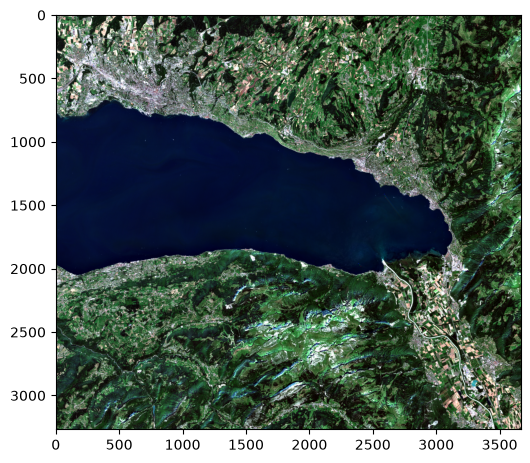

In [5]:
# TODO: visualize natural color image using matplotlib 
#       Note: before calling plt.imshow() 
#             you can change the size of the visualized image using the command 
#             plt.figure(figsize = (6,6)) 
#             use the value of figsize that you prefer
plt.figure(figsize = (6,6)) 
plt.imshow(natural_color_arr_norm)

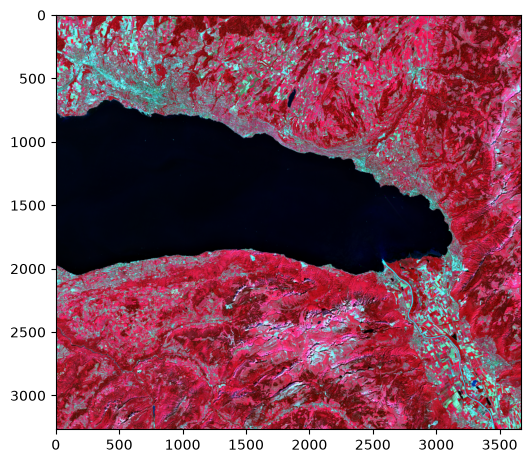

In [6]:
# TODO: visualize false color composite image using matplotlib 
plt.figure(figsize = (6,6))
plt.imshow(false_color_composite_arr_norm)

## 4. Crop images using bounding boxes

Crop the natural color image, and the false composite color image, using the following bounding boxes (in pixel coordinates)
- Region 1 → ***y_min***: 2500, ***x_min***: 3090, ***y_max***: 2590, ***x_max*** 3180
- Region 2 → ***y_min***: 920,  ***x_min***: 1830, ***y_max***: 1120, ***x_max*** 2030

In [7]:
# Remember to Run the cell that contains the function implementation before calling it
def crop_and_save_image(image_array, 
                        y_min, x_min, y_max, x_max, 
                        output_path):
    
    """
    Save a crop of the image delimited by bounding box coordinates
    and returns the numpy array of the cropped image, with shape (height, width, num_bands) 
    
    Parameters
    ==================
    image_array: str
        Image array
    y_min: int
        Minimum vertical coordinate of the bounding box
    x_min: int
        Minimum horizontal coordinate of the bounding box
    y_max: int
        Maximum vertical coordinate of the bounding box
    x_max: int
        Maximum horizontal coordinate of the bounding box
    output_path: str
        Output file path, with extension .tif
    
    Returns
    ==================
    out_image:
        Numpy array of the cropped image, with shape (height, width, num_bands)
    
    """
    
    cropped_image_array = image_array[y_min:y_max+1, x_min:x_max+1]
    
    imsave(output_path, cropped_image_array)
    
    return cropped_image_array

In [8]:
# Bounding box coordinates of the Region 1 (pixel coordinates)
region1_y_min = 2490
region1_x_min = 3090
region1_y_max = 2590
region1_x_max = 3190

# TODO: Use the function crop_and_save_image (defined above) to crop the Region 1,
#       in the natural color image, and the false color composite image,
#       using the bounding box coordinates defined abov
region_1_natural_color_arr = crop_and_save_image(natural_color_arr,
                                                 region1_y_min, region1_x_min,
                                                 region1_y_max, region1_x_max,
                                                 "region_1_natural_color.tif")
region_1_false_composite_color_arr = crop_and_save_image(false_color_composite_arr,
                                                        region1_y_min, region1_x_min,
                                                        region1_y_max, region1_x_max,
                                                        "region_1_false_composite.tif")

/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: region_1_natural_color.tif is a low contrast image
  return func(*args, **kwargs)
/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: region_1_false_composite.tif is a low contrast image
  return func(*args, **kwargs)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [59..4304].


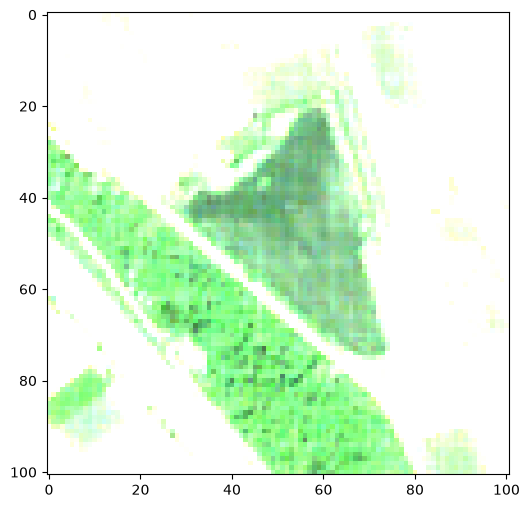

In [9]:
# TODO: Visualize Region 1 in natural color
plt.figure(figsize = (6,6))
plt.imshow(region_1_natural_color_arr)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33..5474].


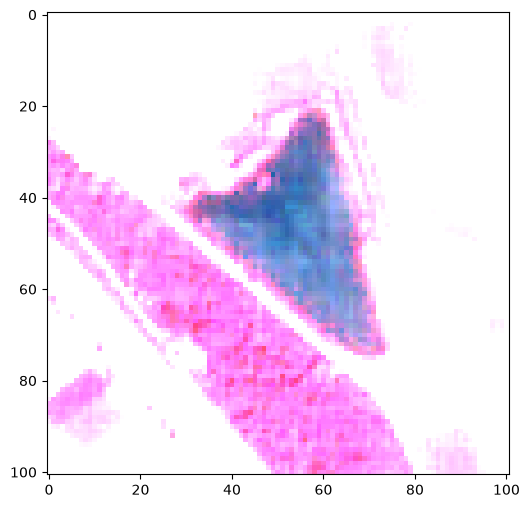

In [10]:
# TODO: Visualize Region 1 in false color composite
plt.figure(figsize = (6,6))
plt.imshow(region_1_false_composite_color_arr)

In [11]:
# Bounding box coordinates of the Region 2 (pixel coordinates)
region2_y_min = 920
region2_x_min = 1830
region2_y_max = 1120
region2_x_max = 2030

# TODO: Use the function crop_and_save_image (defined above) to crop the Region 2,
#       in the natural color image, and the false color composite image,
#       using the bounding box coordinates defined above
region_2_natural_color_arr = crop_and_save_image(natural_color_arr,
                                                 region2_y_min, region2_x_min,
                                                 region2_y_max, region2_x_max,
                                                 "region_2_natural_color.tif")  
region_2_false_composite_color_arr = crop_and_save_image(false_color_composite_arr,
                                                        region2_y_min, region2_x_min,
                                                        region2_y_max, region2_x_max,
                                                        "region_2_false_composite.tif")

/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: region_2_natural_color.tif is a low contrast image
  return func(*args, **kwargs)
/home/justin/EPFL/Earth_Observations/Earth-Observation-Image-Processing/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: region_2_false_composite.tif is a low contrast image
  return func(*args, **kwargs)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..13816].


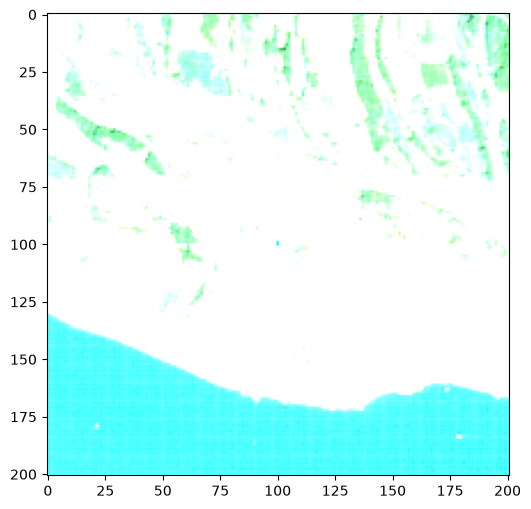

In [12]:
# TODO: Visualize Region 2 in natural color
plt.figure(figsize = (6,6))
plt.imshow(region_2_natural_color_arr)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33..5474].


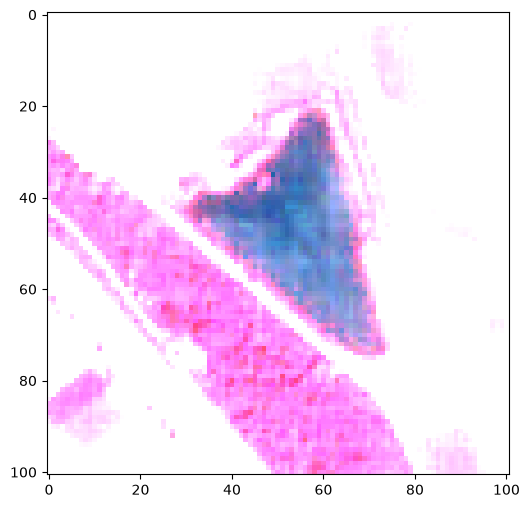

In [13]:
# TODO: Visualize Region 1 in false color composite
plt.figure(figsize = (6,6))
plt.imshow(region_1_false_composite_color_arr)

Square the selected region for broaded understanding.

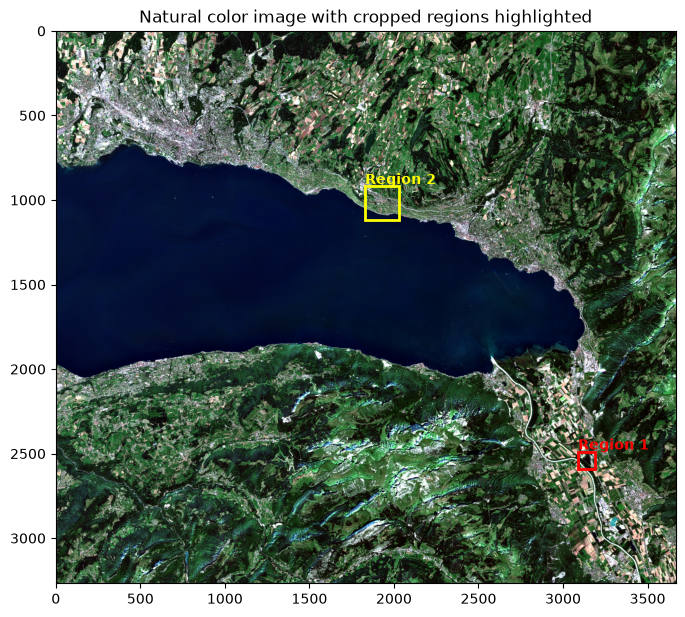

In [14]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(natural_color_arr_norm)

regions = {
    "Region 1": (region1_x_min, region1_y_min, region1_x_max, region1_y_max, "red"),
    "Region 2": (region2_x_min, region2_y_min, region2_x_max, region2_y_max, "yellow"),
}

for label, (x_min, y_min, x_max, y_max, color) in regions.items():
    width = x_max - x_min
    height = y_max - y_min
    rect = patches.Rectangle((x_min, y_min), width, height,
                              linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x_min, y_min - 15, label, color=color, fontsize=10, weight="bold")

ax.set_title("Natural color image with cropped regions highlighted")
plt.show()


In [17]:
# TODO: Which is the shape of the numpy arrays of the two cropped regions?
print("Shape of Region 1:", np.shape(region_1_natural_color_arr))
print("Shape of Region 2:", np.shape(region_2_natural_color_arr))

Shape of Region 1: (101, 101, 3)
Shape of Region 2: (201, 201, 3)


In [ ]:
# TODO: The spatial resolution of the images is 10m. 
#       What is the area in square meters covered by each of the two cropped regions?
area_region_1 = (region1_x_max - region1_x_min + 1) * (region1_y_max - region1_y_min + 1) * 10 * 10
area_region_2 = (region2_x_max - region2_x_min + 1) * (region2_y_max - region2_y_min + 1) * 10 * 10

# Why 10 * 10?
# Because each pixel represents a 10m x 10m area, so the area of each pixel is 100 square meters. 
# To find the total area of the cropped region, we multiply the number of pixels in the region by 100.
print("Area of Region 1:", area_region_1, "square meters")
print("Area of Region 2:", area_region_2, "square meters")

Area of Region 1: 1020100 square meters
Area of Region 2: 4040100 square meters
